# Pendahuluan

* Ini adalah kelanjutan dari `02_Metode_Lain.ipynb`
* Tujuannya adalah untuk membangun model prediksi fleksibilitas keuangan (FFR) menggunakan Regresi Logistik sebagai statistik prediksi machine learning
* Akan dibangun 2 model: Model 1 menggunakan semua variabel, dan Model 2 menggunakan COR saja (didapatkan dari notebook sebelumnya)

# Import dan Load

In [136]:
# Library olah data default
import pandas as pd
import numpy as np

# Warning
import warnings
from sklearn.exceptions import ConvergenceWarning

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Export model
import joblib

In [137]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [138]:
df_fmcg = pd.read_excel('https://drive.google.com/uc?id=1IHnAxLw5kz1QSveCgPCEbPE0FxlYT7jw')

In [139]:
df_fmcg.sample(5)

,Emiten,Tahun,FFR,ROA,TAS,CRO,DTR,RNR,LTA
153,NaN,2023,1,0.058613,0.123344,0.162270,0.479286,0.002925,18.596876
2,NaN,2022,1,0.130252,0.295985,0.169276,0.210631,0.002422,15.813793
38,NaN,2023,0,0.099388,0.235136,0.118978,0.541403,0.002687,17.349086
165,GOOD,2020,1,0.042000,0.509318,0.128818,0.556740,0.001470,15.713272
75,WIIM,2020,1,0.106693,0.185144,0.266070,0.265473,0.031941,14.294500


In [140]:
X = df_fmcg[['ROA', 'TAS', 'CRO', 'DTR', 'RNR', 'LTA']]
y = df_fmcg['FFR']

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, stratify=y)

# Eksplorasi

## Visualisasi Train dan Test

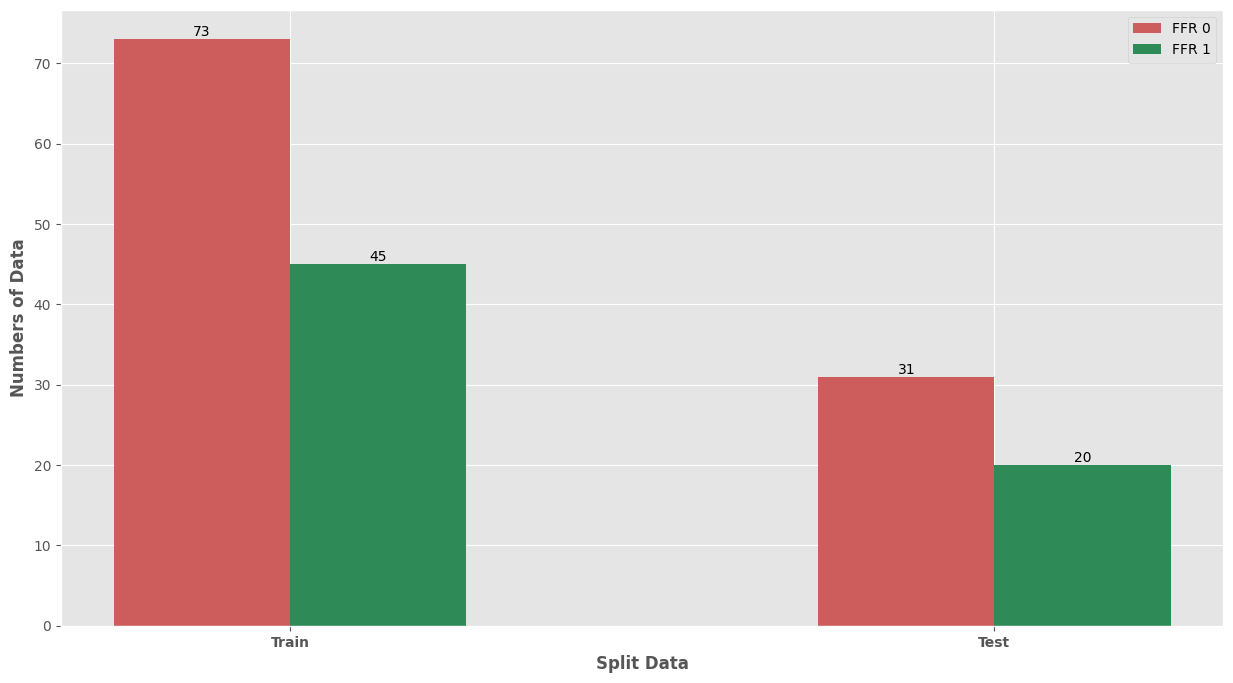

In [142]:
N = 2
ind = np.arange(N)
width = 0.25

def addlabels(bars):
    """Function to add labels to the bars."""
    for bar_group in bars:
        for bar in bar_group:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height,
                     f'{int(height)}',
                     ha='center', va='bottom')


ffr_0_counts = [y_train.value_counts().get(0, 0), y_test.value_counts().get(0, 0)]
bar1 = plt.bar(ind, ffr_0_counts, width, color='indianred')

ffr_1_counts = [y_train.value_counts().get(1, 0), y_test.value_counts().get(1, 0)]
bar2 = plt.bar(ind+width, ffr_1_counts, width, color='seagreen')

addlabels([bar1, bar2])
plt.xlabel("Split Data", fontweight="bold")
plt.ylabel("Numbers of Data", fontweight="bold")

plt.xticks(ind+width/2,['Train', 'Test'], fontweight="bold")
plt.legend( (bar1, bar2), ('FFR 0', 'FFR 1') )
plt.show()

## Visualisasi Variabel CRO terhadap FFR

Nilai CRO dan pembagian kelasnya. Sangat terlihat bahwa jika CRO  lebih dari 0.12 cenderung memiliki FFR bernilai 1. Hal ini sama dengan temuan pada referensi penelitian.

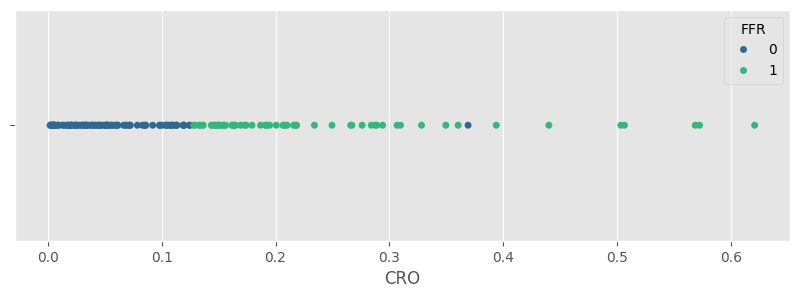

In [143]:
plt.figure(figsize=(10,3))
sns.stripplot(data=df_fmcg, x='CRO', hue='FFR', jitter=False, palette='viridis')
plt.show()

Kerned Density Estimate (KDE) untuk distribusi variabel CRO pada tiap kelas FFR

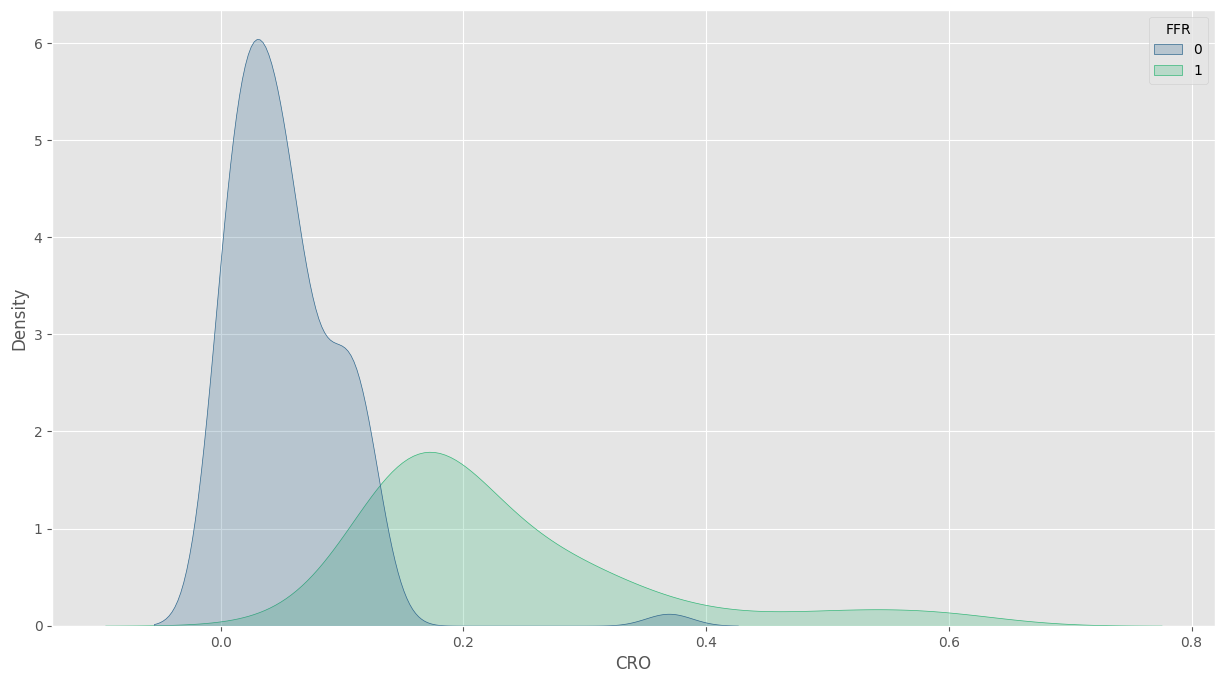

In [144]:
sns.kdeplot(data=df_fmcg, x='CRO', hue='FFR', fill=True, palette='viridis')
plt.show()

# Hyperparameter Tuning

## K-Fold Cross Validation

Menggunakan model Regresi Logistik tanpa tuning sama sekali

Model Logistic Regression (LR) 1, Memasukan seluruh variabel X

In [149]:
lr1_non_tuning = LogisticRegression()
lr1_non_tuning_acc = cross_val_score(lr1_non_tuning, X_train, y_train, scoring="accuracy", cv=5)
print("Akurasi masing-masing = ", lr1_non_tuning_acc)
print("Rata-rata = ", lr1_non_tuning_acc.mean())

Akurasi masing-masing =  [0.79166667 0.75       0.70833333 0.65217391 0.69565217]
Rata-rata =  0.7195652173913044


Model Logistic Regression (LR) 2, Memasukan hanya CRO

In [150]:
lr2_non_tuning = LogisticRegression()
lr2_non_tuning_acc = cross_val_score(lr2_non_tuning, X_train[['CRO']], y_train, scoring="accuracy", cv=5)
print("Akurasi masing-masing = ", lr2_non_tuning_acc)
print("Rata-rata = ", lr2_non_tuning_acc.mean())

Akurasi masing-masing =  [0.70833333 0.75       0.58333333 0.60869565 0.69565217]
Rata-rata =  0.6692028985507247


## Grid Search Cross Validation

In [152]:
parameters_lr = [
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'max_iter': [100, 200, 500]
    },
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [100, 200, 500]
    }
]

#Default Parameter: C=1, Penalty=l2, solver=lbfgs, max_iter=100

In [153]:
lr_tuning = LogisticRegression()

In [154]:
# Suppress convergence and other non-critical warnings during search
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    search_lr1_tuning = GridSearchCV(lr_tuning, parameters_lr, cv=5, scoring='accuracy', verbose=1)
    search_lr1_tuning.fit(X_train, y_train)

print("Best Parameters:", search_lr1_tuning.best_params_)
print("Best Score:", search_lr1_tuning.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters: {'C': 100, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.9579710144927537


In [155]:
# Suppress convergence and other non-critical warnings during search
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=UserWarning)

    search_lr2_tuning = GridSearchCV(lr_tuning, parameters_lr, cv=5, scoring='accuracy', verbose=1)
    search_lr2_tuning.fit(X_train[['CRO']], y_train)

print("Best Parameters:", search_lr2_tuning.best_params_)
print("Best Score:", search_lr2_tuning.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters: {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Score: 0.9659420289855072


## Mendapatkan Model dengan Parameter Terbaik

In [156]:
lr1_tuning = search_lr1_tuning.best_estimator_

In [157]:
lr1_tuning_acc = cross_val_score(lr1_tuning, X_train, y_train, scoring="accuracy", cv=5)
print("Akurasi masing-masing = ", lr1_tuning_acc)
print("Rata-rata = ", lr1_tuning_acc.mean())

Akurasi masing-masing =  [1.         0.95833333 0.875      1.         0.95652174]
Rata-rata =  0.9579710144927537


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [158]:
lr2_tuning = search_lr2_tuning.best_estimator_

In [159]:
lr2_tuning_acc = cross_val_score(lr2_tuning, X_train[['CRO']], y_train, scoring="accuracy", cv=5)
print("Akurasi masing-masing = ", lr2_tuning_acc)
print("Rata-rata = ", lr2_tuning_acc.mean())

Akurasi masing-masing =  [1.         0.95833333 0.95833333 0.95652174 0.95652174]
Rata-rata =  0.9659420289855072


## Visualisasi Sebelum dan Sesudah Tuning

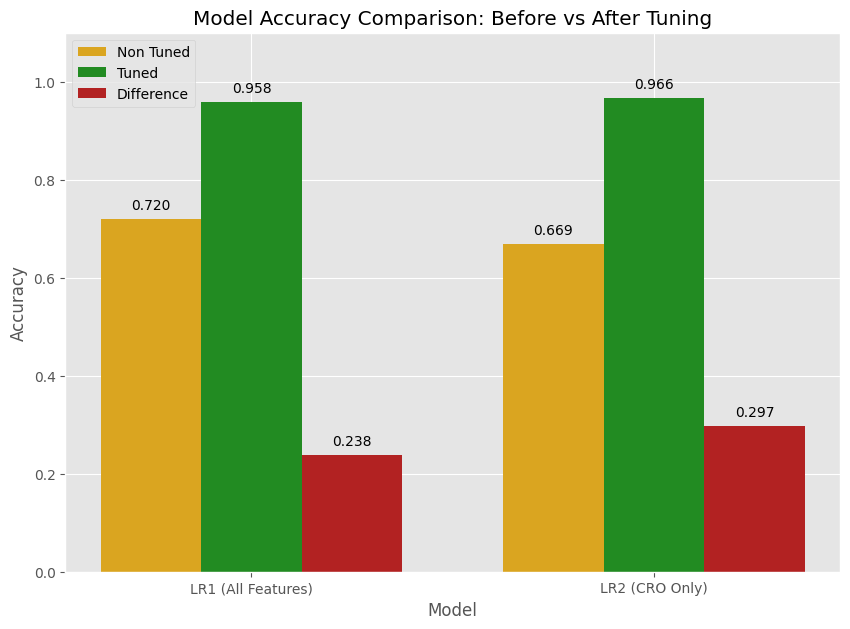

In [160]:
def addlabels(x,y,z):
    for i in range(len(x)):
      plt.text(i, x[i]+0.02, format(x[i], ".3f"), ha = 'center')
      plt.text(i+0.25, y[i]+0.02, format(y[i], ".3f"), ha = 'center')
      plt.text(i+0.5, z[i]+0.02, format(z[i], ".3f"), ha = 'center')

N = 2
ind = np.arange(N)
width = 0.25

plt.figure(figsize=(10,7))
# Mapping to current variables:
# 0: LR1 (All), 1: LR2 (CRO)
non_tuning_acc = [lr1_non_tuning_acc.mean(), lr2_non_tuning_acc.mean()]
bar1 = plt.bar(ind, non_tuning_acc, width, color='goldenrod')

tuning_acc = [lr1_tuning_acc.mean(), lr2_tuning_acc.mean()]
bar2 = plt.bar(ind+width, tuning_acc, width, color='forestgreen')

selisih = []
for i in range(0, len(non_tuning_acc)):
  selisih.append(np.abs(non_tuning_acc[i]-tuning_acc[i]))

bar3 = plt.bar(ind+width*2, selisih, width, color = 'firebrick')

addlabels(non_tuning_acc, tuning_acc, selisih)
plt.xlabel("Model")
plt.ylabel('Accuracy')
plt.ylim([0, 1.1])

plt.xticks(ind+width,['LR1 (All Features)', 'LR2 (CRO Only)'])
plt.legend( (bar1, bar2, bar3), ('Non Tuned', 'Tuned', 'Difference'), loc='upper left' )
plt.title("Model Accuracy Comparison: Before vs After Tuning")
plt.show()

# Model Evaluation

Untuk membantu visualisasi nanti

In [161]:
def plot_evaluation(y_true, y_pred, auc_score, title_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # Manual Confusion Matrix using Seaborn heatmap
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix ({title_suffix})')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    ax[0].set_xticklabels(['FFR 0', 'FFR 1'])
    ax[0].set_yticklabels(['FFR 0', 'FFR 1'])

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title(f'ROC Curve ({title_suffix})')
    ax[1].legend(loc="lower right")
    plt.show()

## Simple Rule-Based Prediction

Dari eksplorasi sebelumnya, kita bisa mendefinisikan model simple rule-based, yaitu if `CRO >= 0.12`, then `FFR = 1`.

In [162]:
# Define the rule-based prediction function
def simple_predict(cro_values):
    return [1 if cro >= 0.12 else 0 for cro in cro_values]

def simple_rule_based_classifier(X, y, set_name):
    preds = simple_predict(X['CRO'])
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec = recall_score(y, preds)
    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, preds)

    print(f"--- {set_name} Metrics ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}\n")
    return preds, auc

# Evaluate Train
y_pred_train_srb, auc_train_srb = simple_rule_based_classifier(X_train, y_train, 'Train')

# Evaluate Test
y_pred_test_srb, auc_test_srb = simple_rule_based_classifier(X_test, y_test, 'Test')

--- Train Metrics ---
Accuracy: 0.9746
Precision: 0.9565
Recall: 0.9778
F1 Score: 0.9670
ROC-AUC: 0.9752

--- Test Metrics ---
Accuracy: 0.9804
Precision: 0.9524
Recall: 1.0000
F1 Score: 0.9756
ROC-AUC: 0.9839



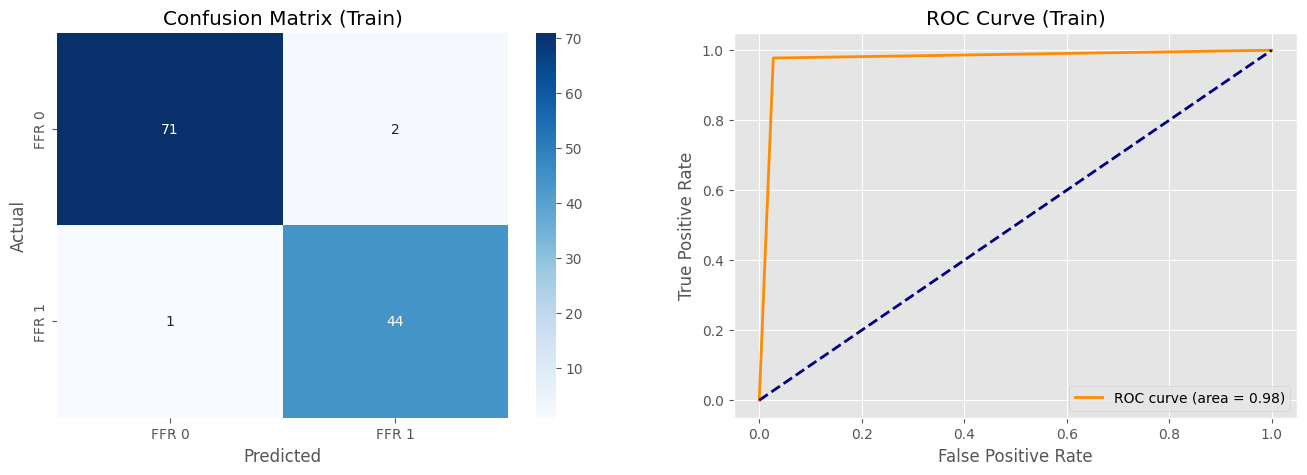

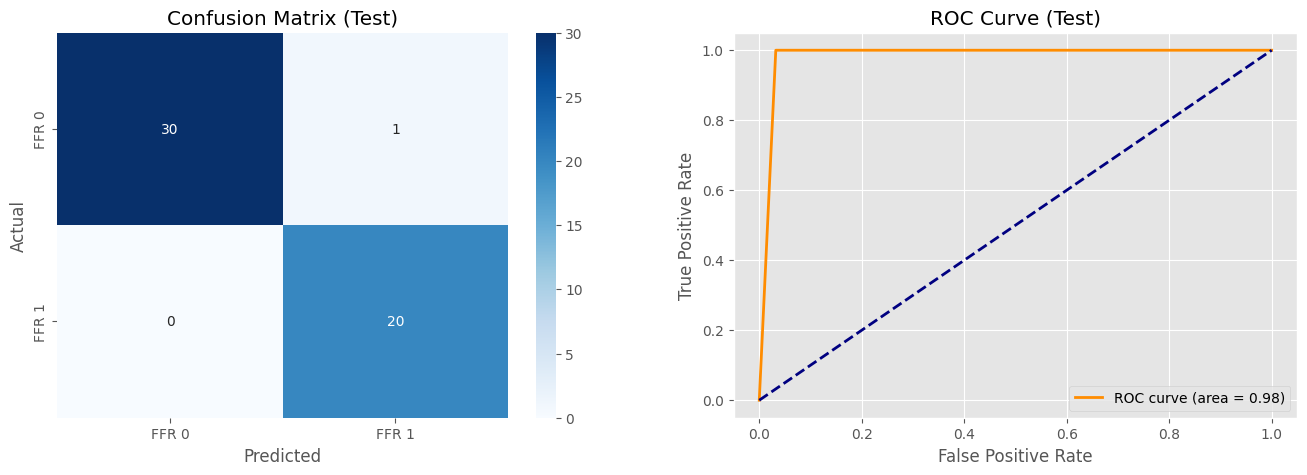

In [163]:
# Plot Train
plot_evaluation(y_train, y_pred_train_srb, auc_train_srb, 'Train')

# Plot Test
plot_evaluation(y_test, y_pred_test_srb, auc_test_srb, 'Test')

## LR1 (Semua Variabel)

In [164]:
def evaluate_model_lr(y_true, y_pred, y_prob, set_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"--- {set_name} Metrics ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}\n")
    return auc

In [165]:
# LR1 Final Model
lr1_final = lr1_tuning # Already defined from GridSearchCV

print("=== Final Evaluation: LR1 (All Features) ===")
# Train
y_pred_train_lr1 = lr1_final.predict(X_train)
y_prob_train_lr1 = lr1_final.predict_proba(X_train)[:, 1]
auc_train_lr1 = evaluate_model_lr(y_train, y_pred_train_lr1, y_prob_train_lr1, 'Train')

# Test
y_pred_test_lr1 = lr1_final.predict(X_test)
y_prob_test_lr1 = lr1_final.predict_proba(X_test)[:, 1]
auc_test_lr1 = evaluate_model_lr(y_test, y_pred_test_lr1, y_prob_test_lr1, 'Test')

=== Final Evaluation: LR1 (All Features) ===
--- Train Metrics ---
Accuracy: 0.9746
Precision: 0.9773
Recall: 0.9556
F1 Score: 0.9663
ROC-AUC: 0.9790

--- Test Metrics ---
Accuracy: 0.9216
Precision: 1.0000
Recall: 0.8000
F1 Score: 0.8889
ROC-AUC: 0.9968



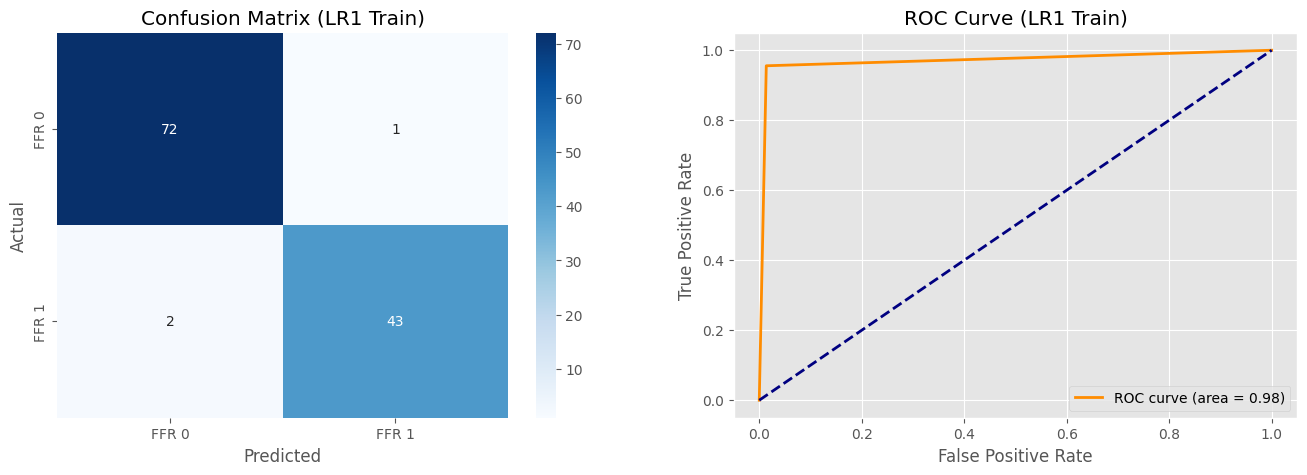

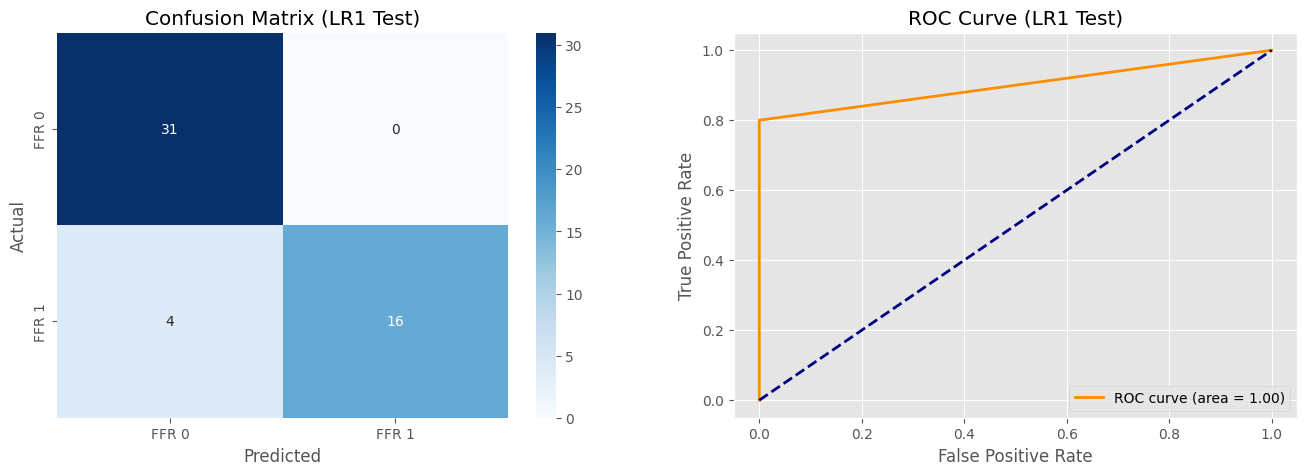

In [166]:
# Plot Train
plot_evaluation(y_train, y_pred_train_lr1, auc_train_lr1, 'LR1 Train')

# Plot Test
plot_evaluation(y_test, y_pred_test_lr1, auc_test_lr1, 'LR1 Test')

## LR2 (CRO)

In [167]:
# LR2 Final Model
lr2_final = lr2_tuning # Already defined from GridSearchCV

print("=== Final Evaluation: LR2 (CRO Only) ===")
# Train
y_pred_train_lr2 = lr2_final.predict(X_train[['CRO']])
y_prob_train_lr2 = lr2_final.predict_proba(X_train[['CRO']])[:, 1]
auc_train_lr2 = evaluate_model_lr(y_train, y_pred_train_lr2, y_prob_train_lr2, 'Train')

# Test
y_pred_test_lr2 = lr2_final.predict(X_test[['CRO']])
y_prob_test_lr2 = lr2_final.predict_proba(X_test[['CRO']])[:, 1]
auc_test_lr2 = evaluate_model_lr(y_test, y_pred_test_lr2, y_prob_test_lr2, 'Test')

=== Final Evaluation: LR2 (CRO Only) ===
--- Train Metrics ---
Accuracy: 0.9661
Precision: 0.9767
Recall: 0.9333
F1 Score: 0.9545
ROC-AUC: 0.9796

--- Test Metrics ---
Accuracy: 0.9412
Precision: 1.0000
Recall: 0.8500
F1 Score: 0.9189
ROC-AUC: 1.0000



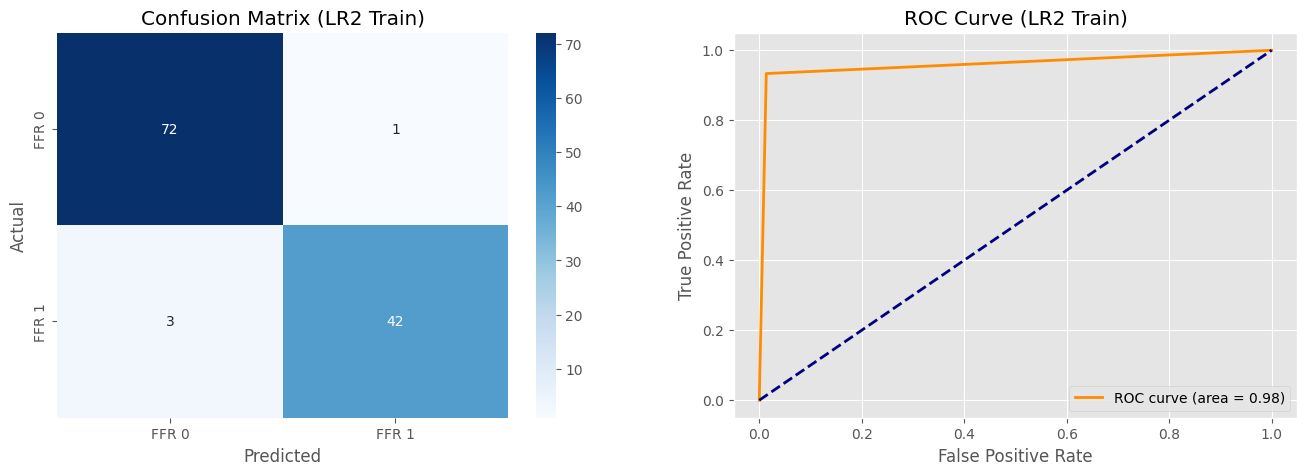

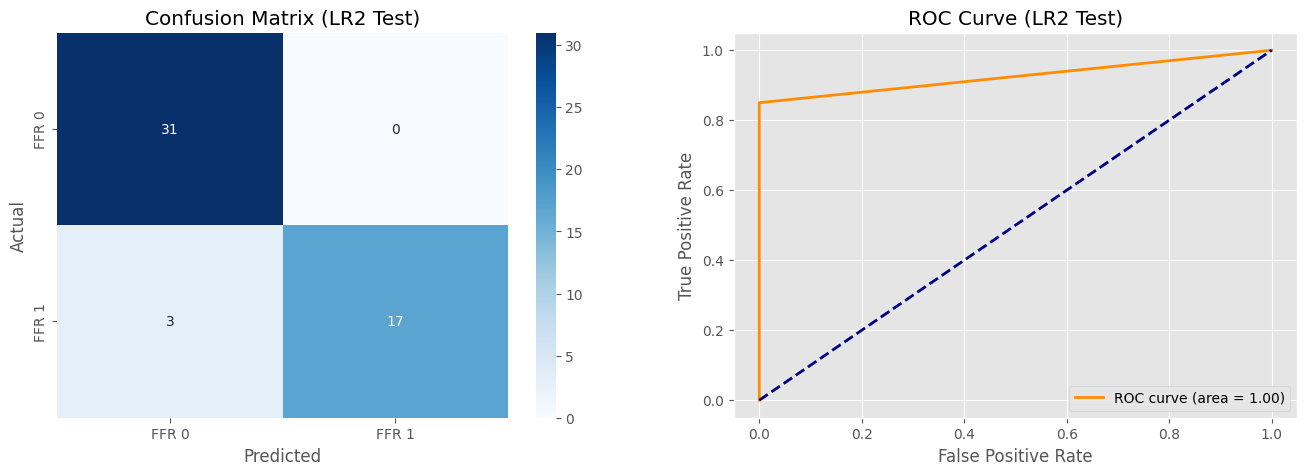

In [168]:
# Plot Train
plot_evaluation(y_train, y_pred_train_lr2, auc_train_lr2, 'LR2 Train')

# Plot Test
plot_evaluation(y_test, y_pred_test_lr2, auc_test_lr2, 'LR2 Test')

## Hasil Akhir

In [171]:
def draw_model_comparison(scores, title, model_names, colors=None):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    n_metrics = len(metrics)
    n_models = len(model_names)
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    plt.figure(figsize=(15, 6))
    x = np.arange(n_metrics)
    width = 0.2

    for i in range(n_models):
        model_scores = scores[i]
        bars = plt.bar(x + (i * width), model_scores, width, label=model_names[i], color=colors[i])
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(x + width, metrics, fontsize=12, fontweight='bold')
    plt.ylim(0, 1.3)
    plt.ylabel('Score')
    plt.legend(loc='upper right')
    plt.show()

def get_metrics_list(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        roc_auc_score(y_true, y_prob)
    ]

# Custom Colors
custom_colors = ['indianred', 'cornflowerblue', 'seagreen']

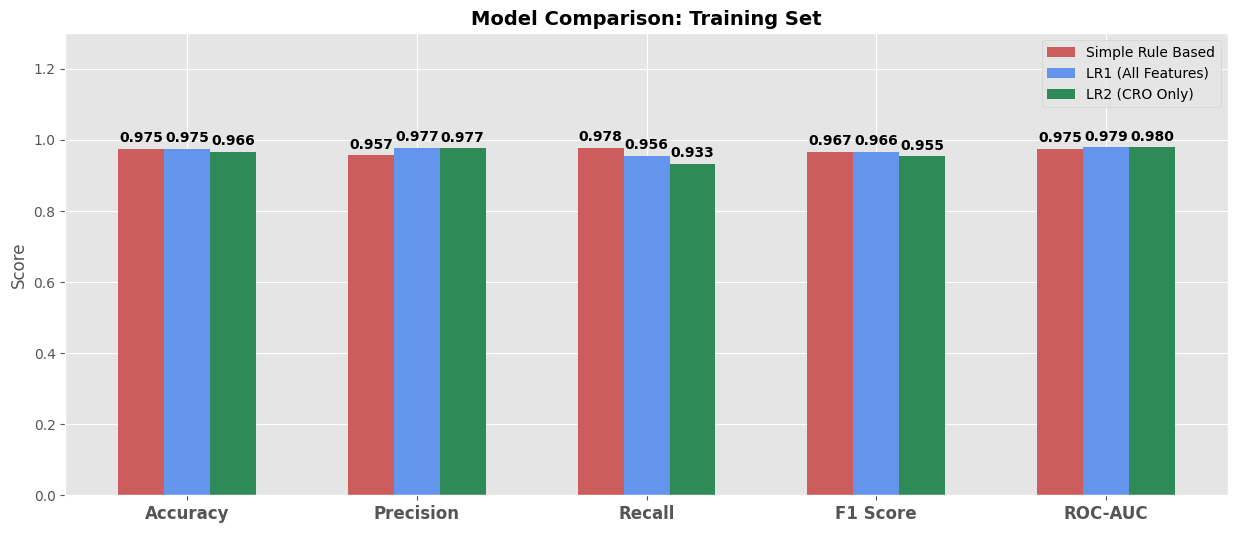

In [172]:
# Prepare Train Data
model_names = ['Simple Rule Based', 'LR1 (All Features)', 'LR2 (CRO Only)']
train_scores = [
    get_metrics_list(y_train, y_pred_train_srb, y_pred_train_srb),
    get_metrics_list(y_train, y_pred_train_lr1, y_prob_train_lr1),
    get_metrics_list(y_train, y_pred_train_lr2, y_prob_train_lr2)
]

draw_model_comparison(train_scores, "Model Comparison: Training Set", model_names, custom_colors)

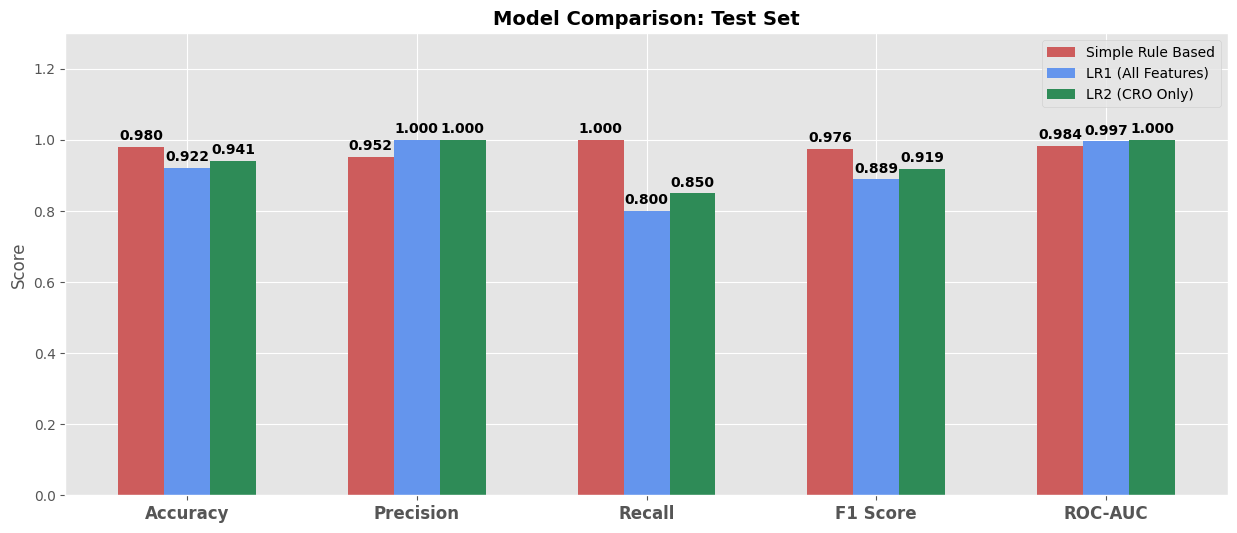

In [173]:
test_scores = [
    get_metrics_list(y_test, y_pred_test_srb, y_pred_test_srb),
    get_metrics_list(y_test, y_pred_test_lr1, y_prob_test_lr1),
    get_metrics_list(y_test, y_pred_test_lr2, y_prob_test_lr2)
]

draw_model_comparison(test_scores, "Model Comparison: Test Set", model_names, custom_colors)

# Export Model dan Kesimpulan

Model 2 dinilai lebih baik dan juga memerlukan input lebih sedikit daripada Model 1.

In [174]:
# Exporting the LR2 final model to a .pkl file
model_filename = 'lr2_final_model.pkl'
joblib.dump(lr2_final, model_filename)

print(f"Model exported successfully as {model_filename}")

Model exported successfully as lr2_final_model.pkl


* Telah berhasil dibangun model Regresi Logistik dengan performa yang sangat baik.
* Regresi Logistik yang dipakai adalah LR2, karena memiliki performa yang lebih baik daripada LR1. Selain itu juga LR2 lebih ringan karena hanya membutuhkan CRO saja. Lebih lanjut lagi juga mempermudah input karena tidak harus memasukan seluruh variabel.
* Model Simple Rule-Based juga cukup baik, cukup hanya menggunakan logika `if CRO >= 0.12 then FFR=1, else FFR=0`. Ini juga didapatkan dari referensi utama. Model ini memiliki performa kecepatan paling cepat karena tidak ada menggunakan algoritma machine learning apapun.